# 3DS Screen Detection and Perspective Warp

This notebook replicates the Nintendo 3DS screen detection logic from the `sh-3ds` project using Python and OpenCV.

In [1]:
import cv2
import numpy as np
import os
import glob
import matplotlib.pyplot as plt

class Config:
    brightness_threshold = 80
    min_area_fraction = 0.02
    max_area_fraction = 0.5
    top_aspect_ratio = 400.0 / 240.0
    bottom_aspect_ratio = 320.0 / 240.0
    aspect_ratio_tolerance = 0.25
    morph_kernel_size = 5
    poly_epsilon_fraction = 0.02
    target_width_top = 400
    target_height_top = 240
    target_width_bot = 320
    target_height_bot = 240

## Core Functions

In [2]:
def order_corners(pts):
    """Order corners as TL, TR, BR, BL."""
    pts = np.array(pts, dtype="float32")
    s = pts.sum(axis=1)
    diff = np.diff(pts, axis=1)
    
    ordered = np.zeros((4, 2), dtype="float32")
    ordered[0] = pts[np.argmin(s)]       # TL
    ordered[1] = pts[np.argmin(diff)]    # TR
    ordered[2] = pts[np.argmax(s)]       # BR
    ordered[3] = pts[np.argmax(diff)]    # BL
    return ordered

def validate_corner_order(corners):
    """Validate that ordered corners form a sensible quadrilateral."""
    cx, cy = np.mean(corners, axis=0)
    tl, tr, br, bl = corners
    return (
        tl[0] < cx and tl[1] < cy and
        tr[0] > cx and tr[1] < cy and
        br[0] > cx and br[1] > cy and
        bl[0] < cx and bl[1] > cy
    )

def compute_aspect_ratio(corners):
    tl, tr, br, bl = corners
    top_w = np.linalg.norm(tr - tl)
    bot_w = np.linalg.norm(br - bl)
    avg_w = (top_w + bot_w) / 2.0
    
    left_h = np.linalg.norm(bl - tl)
    right_h = np.linalg.norm(br - tr)
    avg_h = (left_h + right_h) / 2.0
    
    if avg_h < 1.0: return 0.0
    return avg_w / avg_h

def compute_confidence(corners, aspect_ratio, config):
    top_diff = abs(aspect_ratio - config.top_aspect_ratio)
    bot_diff = abs(aspect_ratio - config.bottom_aspect_ratio)
    best_diff = min(top_diff, bot_diff)
    
    conf = 1.0 - (best_diff / (config.aspect_ratio_tolerance * 2.0))
    conf = max(0.0, min(1.0, conf))
    
    tl, tr, br, bl = corners
    tw, bw = np.linalg.norm(tr - tl), np.linalg.norm(br - bl)
    lh, rh = np.linalg.norm(bl - tl), np.linalg.norm(br - tr)
    
    mw, mh = max(tw, bw), max(lh, rh)
    if mw < 1.0 or mh < 1.0: return 0.0
    
    wr = min(tw, bw) / mw
    hr = min(lh, rh) / mh
    return conf * (wr + hr) / 2.0

def find_candidates(frame, config):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    
    # Try Otsu first
    otsu_thresh, binary = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
    if otsu_thresh < config.brightness_threshold:
        _, binary = cv2.threshold(blurred, config.brightness_threshold, 255, cv2.THRESH_BINARY)
        
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (config.morph_kernel_size, config.morph_kernel_size))
    cleaned = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_OPEN, kernel)
    
    contours, _ = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    frame_area = frame.shape[0] * frame.shape[1]
    min_area = config.min_area_fraction * frame_area
    max_area = config.max_area_fraction * frame_area
    
    candidates = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < min_area or area > max_area:
            continue
            
        epsilon = config.poly_epsilon_fraction * cv2.arcLength(cnt, True)
        approx = cv2.approxPolyDP(cnt, epsilon, True)
        
        if len(approx) != 4 or not cv2.isContourConvex(approx):
            continue
            
        corners = order_corners(approx.reshape(4, 2))
        if not validate_corner_order(corners):
            continue
            
        ar = compute_aspect_ratio(corners)
        if abs(ar - config.top_aspect_ratio) > config.aspect_ratio_tolerance and \
           abs(ar - config.bottom_aspect_ratio) > config.aspect_ratio_tolerance:
            continue
            
        conf = compute_confidence(corners, ar, config)
        candidates.append({'corners': corners, 'confidence': conf, 'aspect_ratio': ar})
        
    return candidates

def classify_candidates(candidates, config):
    if not candidates:
        return None, None
        
    # Take top 2 by confidence
    candidates = sorted(candidates, key=lambda x: x['confidence'], reverse=True)[:2]
    
    # Sort by Y position
    candidates = sorted(candidates, key=lambda x: (x['corners'][0][1] + x['corners'][2][1]) / 2.0)
    
    if len(candidates) == 2:
        return candidates[0], candidates[1]
    else:
        # Handle single screen (simplified - assumes top if more likely by AR)
        ar = candidates[0]['aspect_ratio']
        if abs(ar - config.top_aspect_ratio) < abs(ar - config.bottom_aspect_ratio):
            return candidates[0], None
        return None, candidates[0]

def warp_screen(frame, corners, target_w, target_h):
    dst = np.array([
        [0, 0],
        [target_w, 0],
        [target_w, target_h],
        [0, target_h]
    ], dtype="float32")
    M = cv2.getPerspectiveTransform(corners, dst)
    return cv2.warpPerspective(frame, M, (target_w, target_h))

def get_fixed_warp_matrices(image_files, config):
    top_corners_list = []
    bot_corners_list = []
    
    for img_path in image_files[:3]:
        frame = cv2.imread(img_path)
        if frame is None: continue
        candidates = find_candidates(frame, config)
        top, bot = classify_candidates(candidates, config)
        if top:
            top_corners_list.append(top['corners'])
        if bot:
            bot_corners_list.append(bot['corners'])
            
    if not top_corners_list and not bot_corners_list:
        return None, None
        
    M_top = None
    if top_corners_list:
        avg_top_corners = np.mean(top_corners_list, axis=0)
        dst_top = np.array([
            [0, 0],
            [config.target_width_top, 0],
            [config.target_width_top, config.target_height_top],
            [0, config.target_height_top]
        ], dtype="float32")
        M_top = cv2.getPerspectiveTransform(avg_top_corners.astype("float32"), dst_top)
        
    M_bot = None
    if bot_corners_list:
        avg_bot_corners = np.mean(bot_corners_list, axis=0)
        dst_bot = np.array([
            [0, 0],
            [config.target_width_bot, 0],
            [config.target_width_bot, config.target_height_bot],
            [0, config.target_height_bot]
        ], dtype="float32")
        M_bot = cv2.getPerspectiveTransform(avg_bot_corners.astype("float32"), dst_bot)
        
    return M_top, M_bot

def warp_all_frames(image_files, M_top, M_bot, config):
    warped_top_frames = []
    warped_bottom_frames = []
    
    for img_path in image_files:
        frame = cv2.imread(img_path)
        if frame is None: continue
        
        if M_top is not None:
            wt = cv2.warpPerspective(frame, M_top, (config.target_width_top, config.target_height_top))
            warped_top_frames.append(wt)
            
        if M_bot is not None:
            wb = cv2.warpPerspective(frame, M_bot, (config.target_width_bot, config.target_height_bot))
            warped_bottom_frames.append(wb)
            
    return np.array(warped_top_frames), np.array(warped_bottom_frames)

def process_folder_batch(folder_path, config):
    extensions = ['*.png', '*.jpg', '*.jpeg', '*.bmp']
    image_files = []
    for ext in extensions:
        image_files.extend(glob.glob(os.path.join(folder_path, ext)))
    image_files.sort()
    
    if not image_files:
        print(f"No images found in {folder_path}")
        return np.array([]), np.array([])
        
    M_top, M_bot = get_fixed_warp_matrices(image_files, config)
    
    if M_top is None and M_bot is None:
        print("Could not detect screens in first 3 frames.")
        return np.array([]), np.array([])
        
    warped_top, warped_bottom = warp_all_frames(image_files, M_top, M_bot, config)

    return warped_top, warped_bottom


## Main Pipeline

In [3]:
def process_folder(folder_path, config):
    extensions = ['*.png', '*.jpg', '*.jpeg', '*.bmp']
    image_files = []
    for ext in extensions:
        image_files.extend(glob.glob(os.path.join(folder_path, ext)))
    image_files.sort()
    
    if not image_files:
        print(f"No images found in {folder_path}")
        return
        
    for img_path in image_files[:3]: # Process first 5 for preview
        frame = cv2.imread(img_path)
        
        if frame is None: continue
        
        candidates = find_candidates(frame, config)
        top, bot = classify_candidates(candidates, config)
        
        plt.figure(figsize=(15, 5))
        
        # Show detection
        preview = frame.copy()
        if top:
            cv2.polylines(preview, [top['corners'].astype(int)], True, (0, 255, 0), 2)
        if bot:
            cv2.polylines(preview, [bot['corners'].astype(int)], True, (255, 0, 0), 2)
            
        plt.subplot(1, 3, 1)
        plt.title(f"Detection: {os.path.basename(img_path)}")
        plt.imshow(cv2.cvtColor(preview, cv2.COLOR_BGR2RGB))
        
        # Warped Top
        if top:
            warped_top = warp_screen(frame, top['corners'], config.target_width_top, config.target_height_top)
            plt.subplot(1, 3, 2)
            plt.title("Top Screen Warped")
            plt.imshow(cv2.cvtColor(warped_top, cv2.COLOR_BGR2RGB))
            
        # Warped Bot
        if bot:
            warped_bot = warp_screen(frame, bot['corners'], config.target_width_bot, config.target_height_bot)
            plt.subplot(1, 3, 3)
            plt.title("Bottom Screen Warped")
            plt.imshow(cv2.cvtColor(warped_bot, cv2.COLOR_BGR2RGB))
            
        plt.show()

## Run on Folder
Update the `folder_path` below and run.

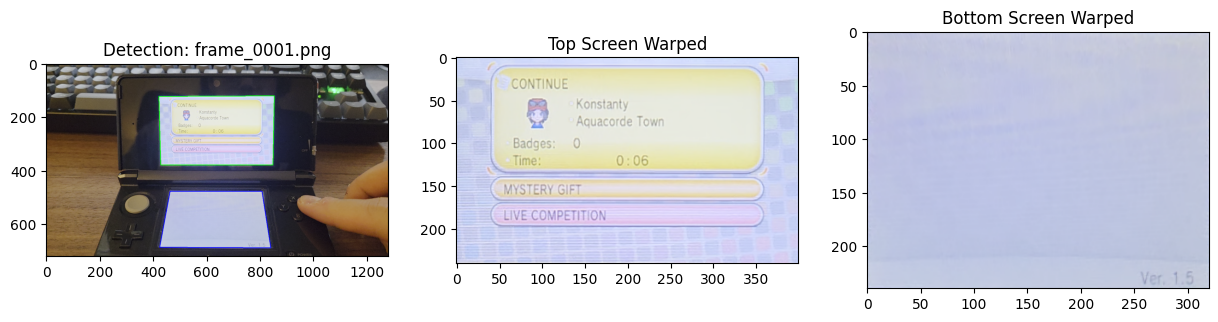

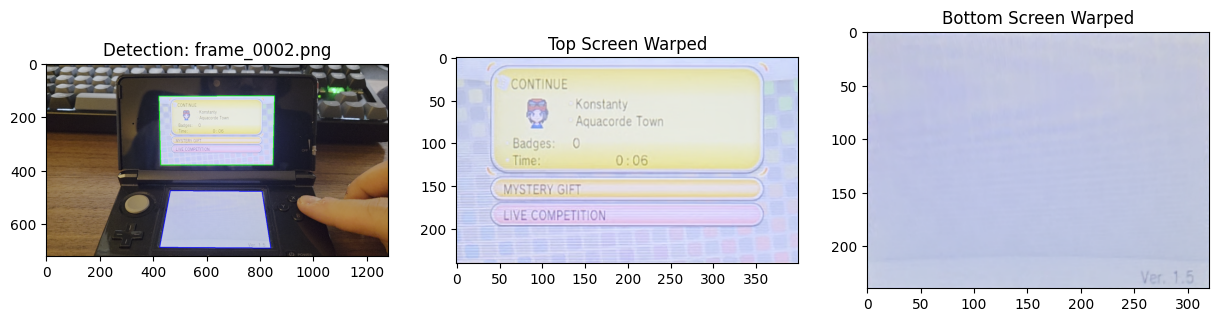

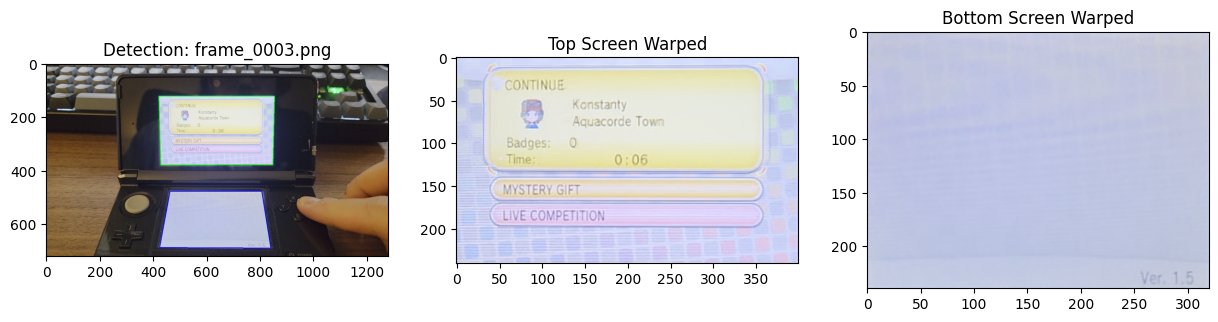

In [4]:

folder_path = R'F:\sh-3ds\video_replays\fennekin_normal\images' # Update this path
config = Config()

# Preview first few frames separately
process_folder(folder_path, config)

In [5]:
# Batch process all frames using warp matrices from first 3 frames
warped_top, warped_bottom = process_folder_batch(folder_path, config)

if warped_top.size > 0:
    print(f"Warped top array shape: {warped_top.shape}")
if warped_bottom.size > 0:
    print(f"Warped bottom array shape: {warped_bottom.shape}")

Warped top array shape: (605, 240, 400, 3)
Warped bottom array shape: (605, 240, 320, 3)


## Intensity Analysis

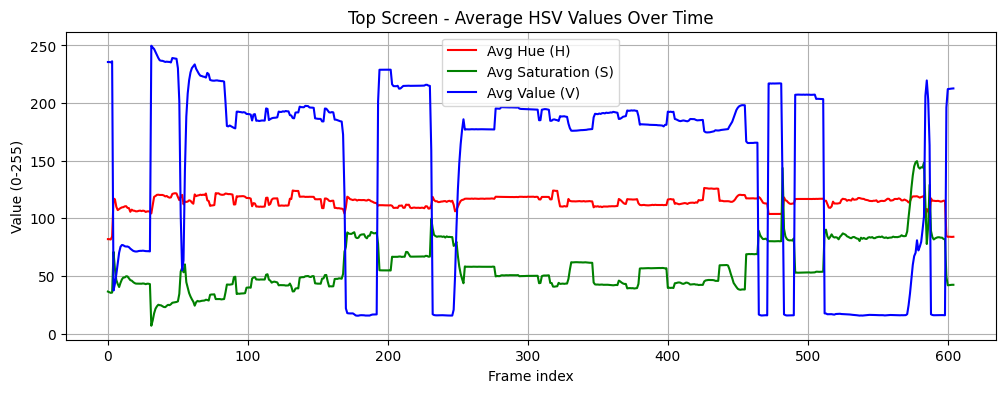

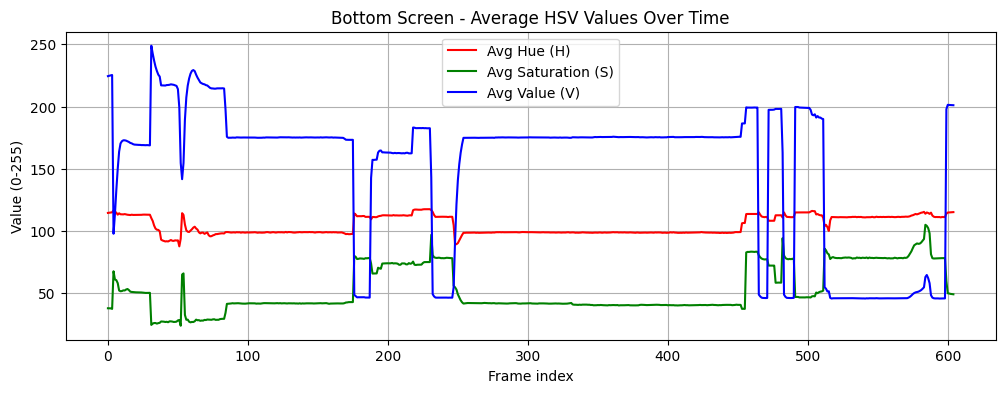

In [6]:
# Plot average image HSV over time
def plot_screen_stats(frames, title_prefix):
    if frames.size == 0:
        return
    
    # HSV transformation and means
    hsv_frames = np.array([cv2.cvtColor(f, cv2.COLOR_BGR2HSV) for f in frames])
    h_avg = np.mean(hsv_frames[..., 0], axis=(1, 2))
    s_avg = np.mean(hsv_frames[..., 1], axis=(1, 2))
    v_avg = np.mean(hsv_frames[..., 2], axis=(1, 2))
        
    # Plot HSV
    plt.figure(figsize=(12, 4))
    plt.plot(h_avg, label='Avg Hue (H)', color='red')
    plt.plot(s_avg, label='Avg Saturation (S)', color='green')
    plt.plot(v_avg, label='Avg Value (V)', color='blue')
    plt.title(f'{title_prefix} - Average HSV Values Over Time')
    plt.xlabel('Frame index')
    plt.ylabel('Value (0-255)')
    plt.grid(True)
    plt.legend()
    plt.show()

if 'warped_top' in locals():
    plot_screen_stats(warped_top, 'Top Screen')

if 'warped_bottom' in locals():
    plot_screen_stats(warped_bottom, 'Bottom Screen')


## Enhanced Adaptive Correction (WB + CLAHE + Gamma)

Applying Enhanced Adaptive WB (White Balance + CLAHE + Gamma)...


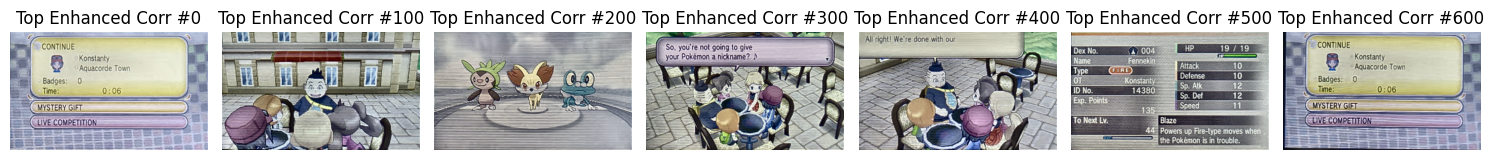

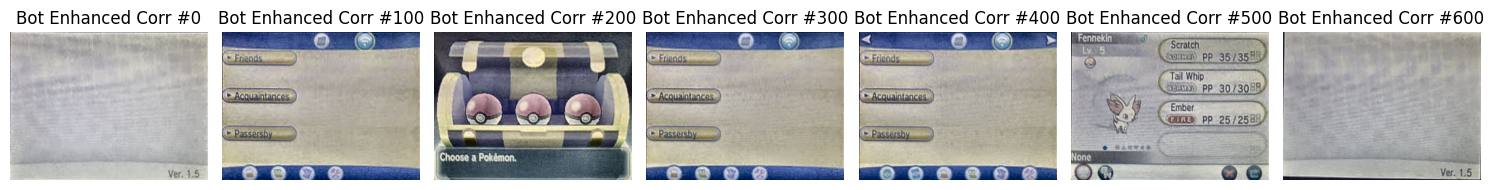

Plotting enhanced corrected stats...


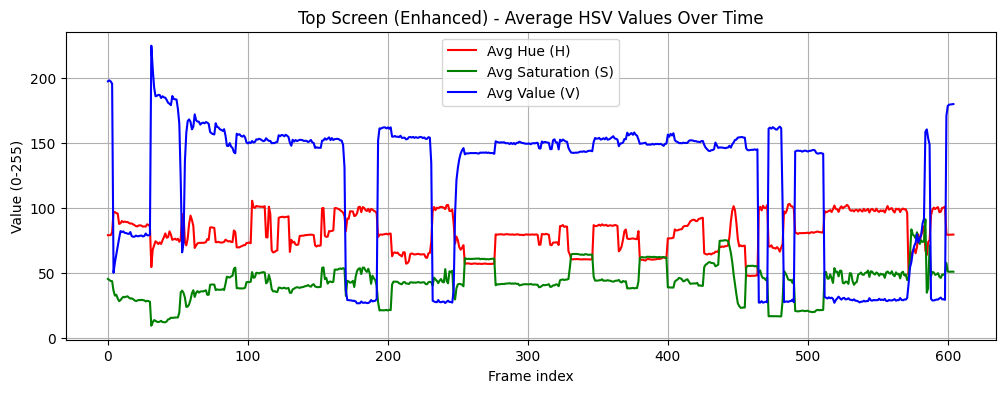

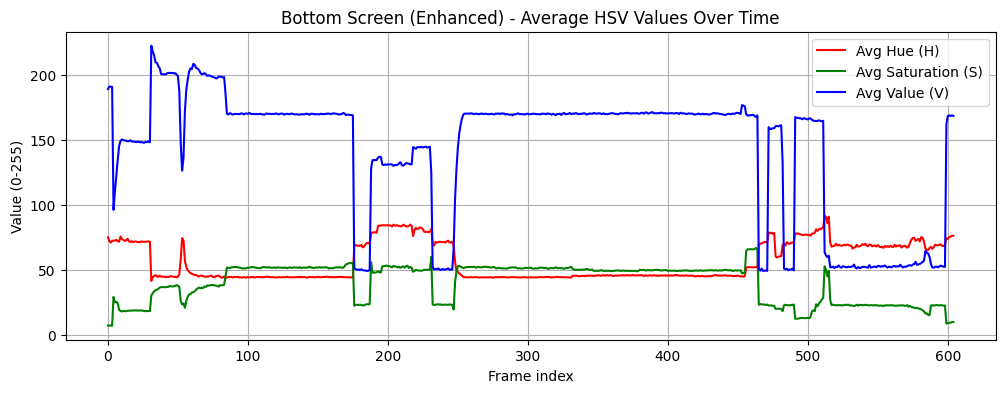

In [7]:
def enhanced_wb(img):
    # Step 1: Gray World WB in float space [0, 1]
    img_float = img.astype(np.float32) / 255.0
    means = np.mean(img_float, axis=(0,1))
    gray_mean = np.mean(means)
    
    # Prevent division by zero and limit extremely high gains
    safe_means = np.where(means > 1e-4, means, 1e-4)
    gains = gray_mean / safe_means
    gains = np.clip(gains, 0.5, 3.0)
    
    corrected = img_float * gains
    corrected = np.clip(corrected, 0, 1)
    
    # Step 2: LAB CLAHE for contrast enhancement (Luminance only)
    lab = cv2.cvtColor((corrected * 255).astype(np.uint8), cv2.COLOR_BGR2LAB)
    clahe = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(6,6))
    lab[:,:,0] = clahe.apply(lab[:,:,0])
    corrected_bgr = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)
    
    # Step 3: Gamma Correction to darken shadows (Gamma > 1)
    gamma = 1.1
    corrected_final = np.power(corrected_bgr / 255.0, gamma) * 255.0
    return np.clip(corrected_final, 0, 255).astype(np.uint8)

def apply_advanced_correction(frames):
    if frames.size == 0:
        return np.array([])
    
    return np.array([enhanced_wb(f) for f in frames])

print("Applying Enhanced Adaptive WB (White Balance + CLAHE + Gamma)...")
warped_top_corr = apply_advanced_correction(warped_top) if 'warped_top' in locals() else np.array([])
warped_bottom_corr = apply_advanced_correction(warped_bottom) if 'warped_bottom' in locals() else np.array([])

# Display every 100th frame
def show_samples(frames, title):
    if frames.size == 0:
        return
    n = len(frames)
    step = 100
    indices = list(range(0, n, step))
    
    plt.figure(figsize=(15, 5))
    for i, idx in enumerate(indices):
        plt.subplot(1, len(indices), i + 1)
        plt.imshow(cv2.cvtColor(frames[idx], cv2.COLOR_BGR2RGB))
        plt.title(f"{title} #{idx}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

if warped_top_corr.size > 0:
    show_samples(warped_top_corr, 'Top Enhanced Corr')
if warped_bottom_corr.size > 0:
    show_samples(warped_bottom_corr, 'Bot Enhanced Corr')

# Plot stats for corrected frames
print("Plotting enhanced corrected stats...")
if warped_top_corr.size > 0:
    plot_screen_stats(warped_top_corr, 'Top Screen (Enhanced)')
if warped_bottom_corr.size > 0:
    plot_screen_stats(warped_bottom_corr, 'Bottom Screen (Enhanced)')


## ROI Specific HSV Analysis

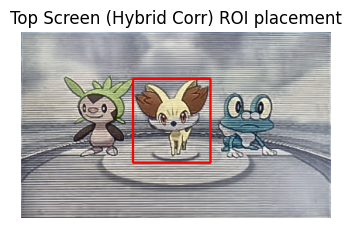

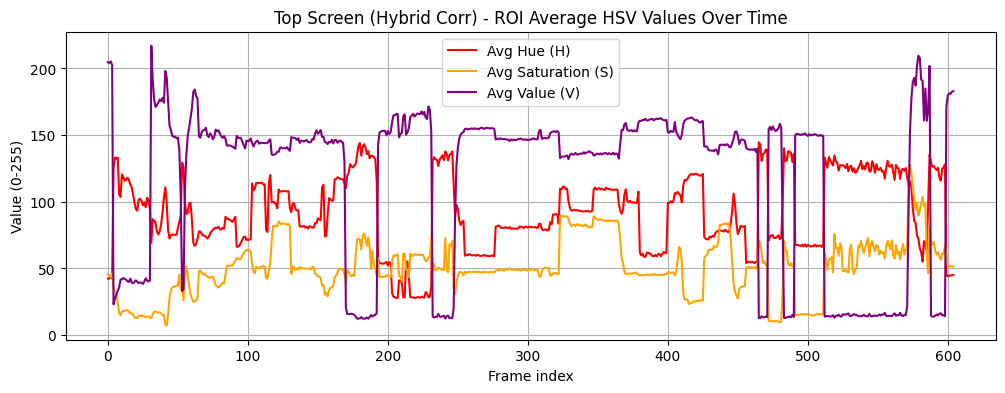

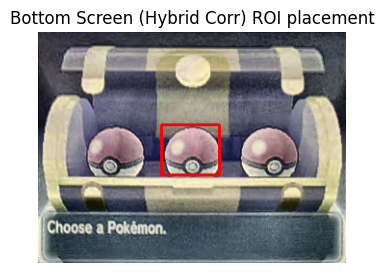

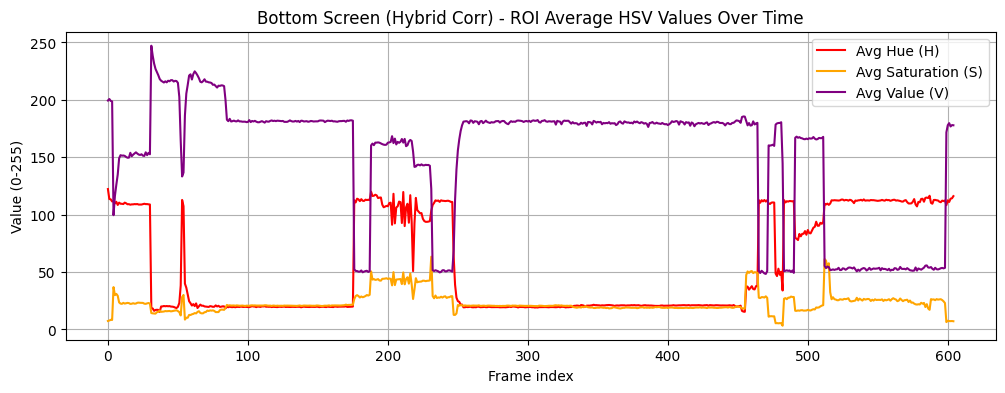

In [8]:
def plot_roi_hsv(frames, roi_rect, title_prefix):
    if frames.size == 0:
        return
    
    # ROI [x, y, w, h] in normalized coordinates (0-1)
    fh, fw = frames.shape[1:3]
    x0 = int(roi_rect[0] * fw)
    y0 = int(roi_rect[1] * fh)
    w = int(roi_rect[2] * fw)
    h = int(roi_rect[3] * fh)
    
    # Slice ROI
    roi_frames = frames[:, y0:y0+h, x0:x0+w]
    
    # Show ROI visualization on the first segment frame
    sample = frames[200].copy()
    cv2.rectangle(sample, (x0, y0), (x0+w, y0+h), (0, 0, 255), 2)
    plt.figure(figsize=(4, 3))
    plt.imshow(cv2.cvtColor(sample, cv2.COLOR_BGR2RGB))
    plt.title(f"{title_prefix} ROI placement")
    plt.axis('off')
    plt.show()
    
    # HSV transformation and means for ROI
    hsv_roi = np.array([cv2.cvtColor(f, cv2.COLOR_BGR2HSV) for f in roi_frames])
    h_avg = np.mean(hsv_roi[..., 0], axis=(1, 2))
    s_avg = np.mean(hsv_roi[..., 1], axis=(1, 2))
    v_avg = np.mean(hsv_roi[..., 2], axis=(1, 2))
    
    # Plot HSV
    plt.figure(figsize=(12, 4))
    plt.plot(h_avg, label='Avg Hue (H)', color='red')
    plt.plot(s_avg, label='Avg Saturation (S)', color='orange')
    plt.plot(v_avg, label='Avg Value (V)', color='purple')
    plt.title(f'{title_prefix} - ROI Average HSV Values Over Time')
    plt.xlabel('Frame index')
    plt.ylabel('Value (0-255)')
    plt.grid(True)
    plt.legend()
    plt.show()

top_roi = [0.36, 0.25, 0.25, 0.45]
bot_roi = [0.4, 0.4, 0.19, 0.22]

if 'warped_top_corr' in locals() and warped_top_corr.size > 0:
    plot_roi_hsv(warped_top_corr, top_roi, 'Top Screen (Hybrid Corr)')

if 'warped_bottom_corr' in locals() and warped_bottom_corr.size > 0:
    plot_roi_hsv(warped_bottom_corr, bot_roi, 'Bottom Screen (Hybrid Corr)')


## Causal Intensity Event Detection (Drops & Raises)

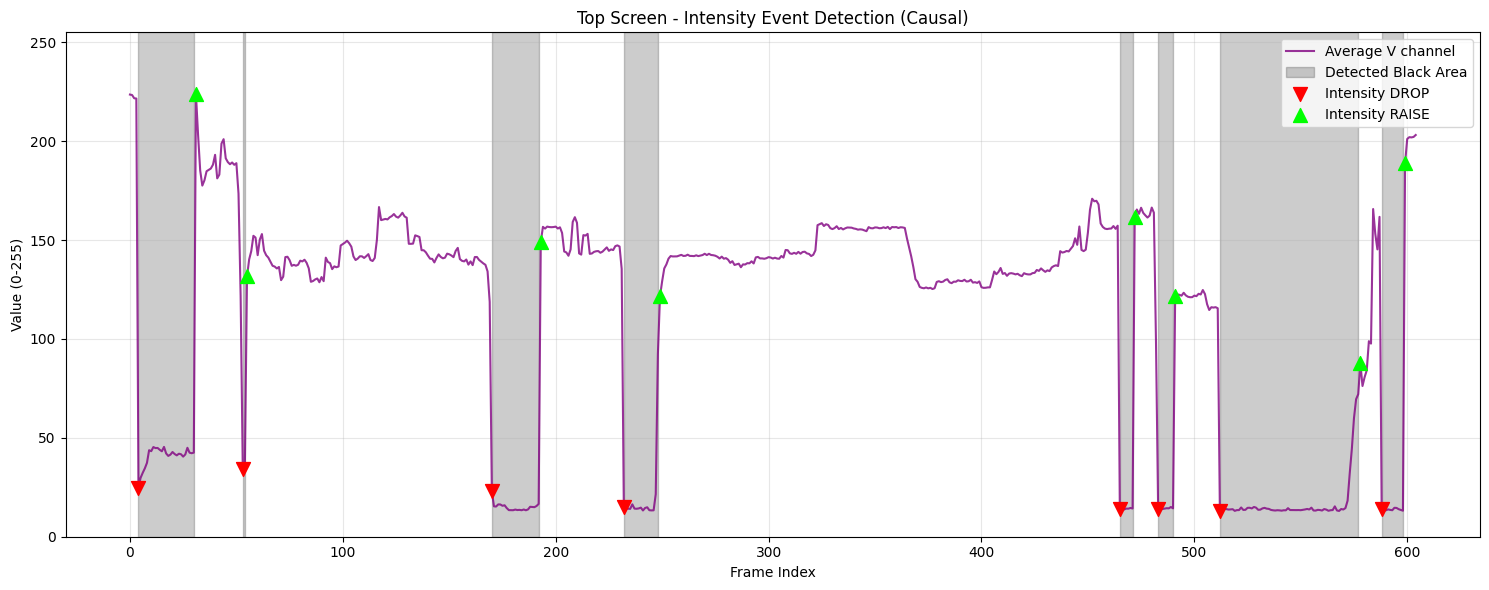

Detected 16 events in Top Screen.
  - Frame    4: DROP
  - Frame   31: RAISE
  - Frame   53: DROP
  - Frame   55: RAISE
  - Frame  170: DROP
  - Frame  193: RAISE
  - Frame  232: DROP
  - Frame  249: RAISE
  - Frame  465: DROP
  - Frame  472: RAISE
  - Frame  483: DROP
  - Frame  491: RAISE
  - Frame  512: DROP
  - Frame  578: RAISE
  - Frame  588: DROP
  - Frame  599: RAISE


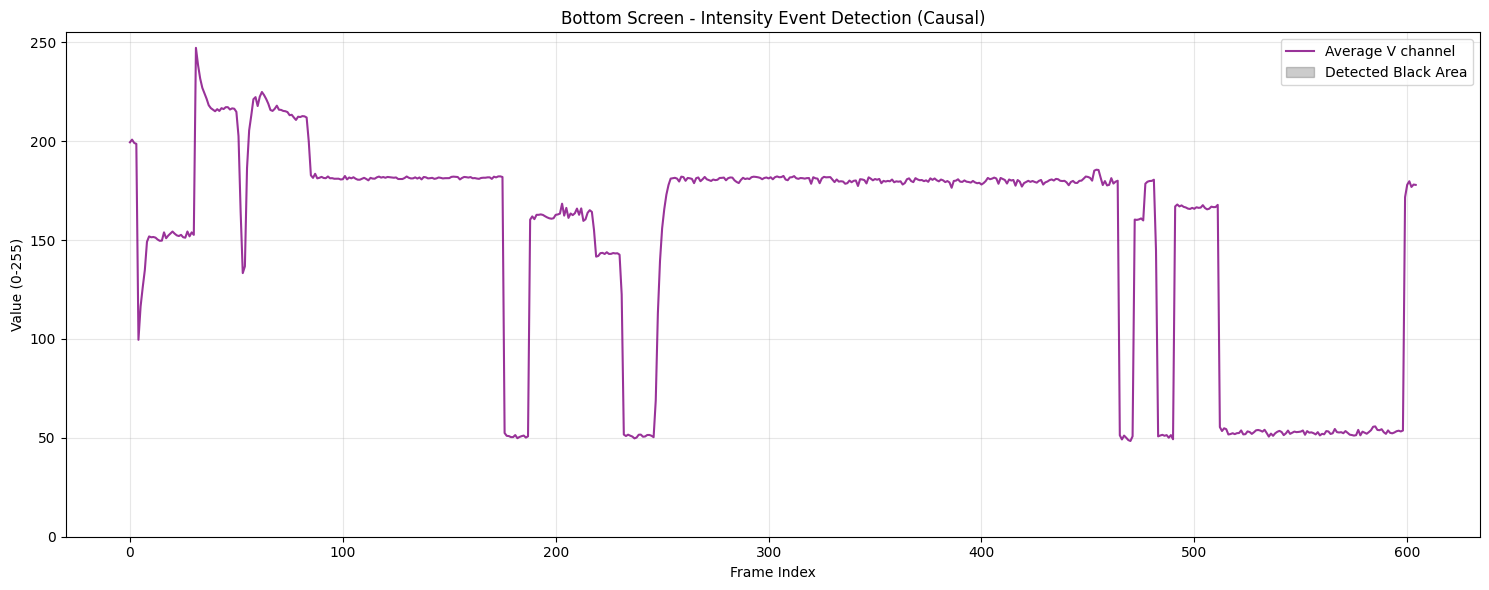

Detected 0 events in Bottom Screen.


In [9]:
class IntensityEventDetector:
    def __init__(self, drop_threshold=0.2, raise_threshold=0.5, window_size=3):
        self.drop_threshold = drop_threshold
        self.raise_threshold = raise_threshold
        self.v_max = 1.0  # Adaptive baseline
        self.is_black = False
        self.window = []
        self.window_size = window_size
        self.events = [] # List of (frame_idx, event_type)
        self.state_history = []
        
    def update(self, v_val, frame_idx):
        # Maintain rolling v_max with very slow decay to adapt to exposure shifts
        if v_val > self.v_max:
            self.v_max = v_val
        else:
            self.v_max *= 0.9995 # Slow decay
            
        # Check state
        if not self.is_black:
            if v_val < (self.drop_threshold * self.v_max):
                self.is_black = True
                self.events.append((frame_idx, 'DROP'))
        else:
            if v_val > (self.raise_threshold * self.v_max):
                self.is_black = False
                self.events.append((frame_idx, 'RAISE'))
                
        self.state_history.append(self.is_black)
        return self.is_black

def analyze_and_plot_events(frames, roi_rect, title_prefix):
    if frames.size == 0:
        return
    
    # ROI Extract and HSV
    fh, fw = frames.shape[1:3]
    x0, y0, w, h = int(roi_rect[0]*fw), int(roi_rect[1]*fh), int(roi_rect[2]*fw), int(roi_rect[3]*fh)
    roi_frames = frames[:, y0:y0+h, x0:x0+w]
    v_vals = np.array([np.mean(cv2.cvtColor(f, cv2.COLOR_BGR2HSV)[..., 2]) for f in roi_frames])
    
    # Run Causal Detector
    detector = IntensityEventDetector()
    for i, v in enumerate(v_vals):
        detector.update(v, i)
        
    # Plotting
    plt.figure(figsize=(15, 6))
    plt.plot(v_vals, color='purple', label='Average V channel', alpha=0.8)
    
    # Shade 'Black' regions
    states = np.array(detector.state_history)
    plt.fill_between(range(len(v_vals)), 0, 255, where=states, color='black', alpha=0.2, label='Detected Black Area')
    
    # Markers
    for f_idx, e_type in detector.events:
        if e_type == 'DROP':
            plt.scatter(f_idx, v_vals[f_idx], color='red', marker='v', s=100, zorder=5, label='Intensity DROP' if 'Intensity DROP' not in plt.gca().get_legend_handles_labels()[1] else "")
        else:
            plt.scatter(f_idx, v_vals[f_idx], color='lime', marker='^', s=100, zorder=5, label='Intensity RAISE' if 'Intensity RAISE' not in plt.gca().get_legend_handles_labels()[1] else "")
            
    plt.title(f"{title_prefix} - Intensity Event Detection (Causal)")
    plt.xlabel("Frame Index")
    plt.ylabel("Value (0-255)")
    plt.ylim(0, 255)
    plt.grid(True, alpha=0.3)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()
    
    print(f"Detected {len(detector.events)} events in {title_prefix}.")
    for f_idx, e_type in detector.events:
        print(f"  - Frame {f_idx:4d}: {e_type}")

bot_roi = [0.4, 0.4, 0.19, 0.22]
top_roi = [0.6, 0.25, 0.25, 0.32]

if 'warped_top_corr' in locals() and warped_top_corr.size > 0:
    analyze_and_plot_events(warped_top_corr, top_roi, 'Top Screen')

if 'warped_bottom_corr' in locals() and warped_bottom_corr.size > 0:
    analyze_and_plot_events(warped_bottom_corr, bot_roi, 'Bottom Screen')


---

## Notebook Summary & C++ Porting Notes

### What This Notebook Does

This notebook implements a **complete video-frame analysis pipeline** for detecting and extracting Nintendo 3DS screens from camera footage, then performing intensity-based event detection on the extracted screen regions.

### Pipeline Stages

| Stage | Cells | Key Functions / Classes | Description |
| --- | --- | --- | --- |
| **1. Configuration** | 1 | `Config` | Defines thresholds for brightness, area fraction, aspect ratios (top: 400×240, bottom: 320×240), morphology kernel, and target warp dimensions. |
| **2. Screen Detection** | 3 | `find_candidates`, `order_corners`, `validate_corner_order`, `compute_aspect_ratio`, `compute_confidence` | Converts frame to grayscale → Otsu/fixed threshold → morphological cleanup → contour finding → polygon approximation → quad validation (convexity, corner order, aspect ratio). Returns scored candidates. |
| **3. Screen Classification** | 3 | `classify_candidates` | Selects top-2 candidates by confidence, sorts by Y-position to assign **top** vs **bottom** screen. Handles single-screen fallback via aspect-ratio proximity. |
| **4. Perspective Warp** | 3 | `warp_screen`, `get_fixed_warp_matrices`, `warp_all_frames` | Computes a **fixed warp matrix** by averaging corners from the first 3 frames (calibration), then applies `cv2.warpPerspective` to all frames with that fixed matrix. |
| **5. Batch Processing** | 5, 7–8 | `process_folder`, `process_folder_batch` | Orchestrates loading images from a folder, running detection, classification, and warping. Outputs numpy arrays of warped frames. |
| **6. HSV Intensity Analysis** | 10 | `plot_screen_stats` | Computes per-frame average H, S, V across the full warped screen and plots time series. |
| **7. Adaptive Color Correction** | 12 | `enhanced_wb`, `apply_advanced_correction` | Three-stage correction: (a) **Gray World White Balance** with clamped gains, (b) **CLAHE** on the L channel in LAB space, (c) **Gamma correction** (γ=1.1). |
| **8. ROI-Specific HSV** | 14 | `plot_roi_hsv` | Extracts a normalized-coordinate ROI from corrected frames, computes and plots per-frame average HSV within that ROI. |
| **9. Causal Event Detection** | 16 | `IntensityEventDetector`, `analyze_and_plot_events` | A **state machine** that tracks a slowly-decaying `v_max` baseline and triggers `DROP` (V < 20% of v_max) and `RAISE` (V > 50% of v_max) events. Plots V-channel with shaded black regions and event markers. |

### Functionalities Suitable for C++ Porting

The following components are **strong candidates** for porting, listed by priority:

1. **`IntensityEventDetector` (Cell 16)** — Pure state-machine logic with no Python/numpy dependencies. Trivially portable. Needs: a struct with `update(float v, int frame_idx)` method, internal state (`v_max`, `is_black`), and an event buffer.

2. **Screen Detection Pipeline (Cell 3)** — `find_candidates` is the core: grayscale → threshold → morphology → `findContours` → `approxPolyDP` → validation. All functions have direct OpenCV C++ equivalents. `order_corners`, `validate_corner_order`, `compute_aspect_ratio`, `compute_confidence` are pure math.

3. **Screen Classification (Cell 3)** — `classify_candidates`: sort-by-confidence, sort-by-Y, assign top/bottom. Simple comparator logic.

4. **Perspective Warp (Cell 3)** — `get_fixed_warp_matrices` (average corners from N calibration frames → `getPerspectiveTransform`) and `warp_all_frames` (`warpPerspective` in a loop). Direct OpenCV C++ API.

5. **Adaptive Color Correction (Cell 12)** — `enhanced_wb`: Gray World WB (per-channel mean → gain), CLAHE on LAB L-channel, gamma LUT. All have OpenCV C++ equivalents; gamma is a simple LUT.

6. **ROI HSV Extraction (Cell 14)** — ROI slicing + `cvtColor(BGR2HSV)` + channel mean. Trivial in C++ with `cv::Mat::operator()` for ROI and `cv::mean()`.

### Key Parameters to Preserve

| Parameter | Value | Used In |
| --- | --- | --- |
| `brightness_threshold` | 80 | Otsu fallback in `find_candidates` |
| `min/max_area_fraction` | 0.02 / 0.5 | Contour area filter |
| `aspect_ratio_tolerance` | 0.25 | AR validation |
| `morph_kernel_size` | 5 | Morphological open/close |
| `poly_epsilon_fraction` | 0.02 | `approxPolyDP` precision |
| `drop_threshold` | 0.2 | Event detector: V < 20% of v_max → DROP |
| `raise_threshold` | 0.5 | Event detector: V > 50% of v_max → RAISE |
| `v_max decay` | 0.9995 | Slow baseline adaptation |
| `CLAHE clipLimit` | 4.0 | Contrast enhancement |
| `Gamma` | 1.1 | Shadow darkening |


---

## Proposed C++ Implementation — Post-Warp Frame Preprocessing

After ScreenDetector + FramePreprocessor produce `DualScreenResult`, the warped images still need
exposure normalization before intensity-based event detection. The notebook implements this as a
3-stage pipeline: **Gray World White Balance → CLAHE → Gamma Correction**.

This should live in `SH3DS::Vision` (alongside existing detectors) as a stateless utility that
operates on individual `cv::Mat` frames in-place or returns a corrected copy.

### Proposed header: `Vision/FrameCorrector.h`

```cpp
#pragma once

#include <opencv2/core.hpp>
#include <opencv2/imgproc.hpp>

namespace SH3DS::Vision
{
    /**
     * @brief Configuration for post-warp frame color correction.
     *
     * Maps directly to the notebook's enhanced_wb() parameters.
     */
    struct FrameCorrectorConfig
    {
        // White Balance
        double wbGainMin  = 0.5;   ///< Minimum per-channel gain clamp
        double wbGainMax  = 3.0;   ///< Maximum per-channel gain clamp

        // CLAHE (applied to L channel in LAB space)
        double claheClipLimit  = 4.0;   ///< Contrast limiting threshold
        int    claheTileWidth  = 6;     ///< Tile grid width
        int    claheTileHeight = 6;     ///< Tile grid height

        // Gamma correction
        double gamma = 1.1;  ///< Gamma value (>1 darkens shadows)
    };

    /**
     * @brief Applies exposure-invariant color correction to a warped screen frame.
     *
     * Pipeline:
     *   1. Gray World White Balance — compute per-channel mean, apply clamped gain.
     *   2. CLAHE on L channel in LAB color space.
     *   3. Gamma correction via LUT.
     *
     * @param frame  Input BGR frame (warped screen). Modified in-place.
     * @param config Correction parameters.
     */
    void CorrectFrame(cv::Mat& frame, const FrameCorrectorConfig& config = {});

} // namespace SH3DS::Vision
```

### Proposed implementation: `Vision/FrameCorrector.cpp`

```cpp
#include "Vision/FrameCorrector.h"

#include <algorithm>
#include <cmath>

namespace SH3DS::Vision
{

void CorrectFrame(cv::Mat& frame, const FrameCorrectorConfig& config)
{
    if (frame.empty()) return;

    // ── Step 1: Gray World White Balance ──────────────────────────
    // Convert to float [0,1], compute per-channel mean, apply gain.
    cv::Mat floatImg;
    frame.convertTo(floatImg, CV_32FC3, 1.0 / 255.0);

    cv::Scalar channelMean = cv::mean(floatImg);
    double grayMean = (channelMean[0] + channelMean[1] + channelMean[2]) / 3.0;

    // Per-channel gain with clamping (matches notebook's safe_means logic)
    std::vector<cv::Mat> channels(3);
    cv::split(floatImg, channels);
    for (int i = 0; i < 3; ++i)
    {
        double safeMean = std::max(channelMean[i], 1e-4);
        double gain = std::clamp(grayMean / safeMean, config.wbGainMin, config.wbGainMax);
        channels[i] *= gain;
    }
    cv::merge(channels, floatImg);
    cv::min(floatImg, 1.0, floatImg);  // clip to [0,1]

    // Back to uint8 for CLAHE
    floatImg.convertTo(frame, CV_8UC3, 255.0);

    // ── Step 2: CLAHE on L channel (LAB space) ───────────────────
    cv::Mat lab;
    cv::cvtColor(frame, lab, cv::COLOR_BGR2Lab);

    std::vector<cv::Mat> labChannels(3);
    cv::split(lab, labChannels);

    auto clahe = cv::createCLAHE(
        config.claheClipLimit,
        cv::Size(config.claheTileWidth, config.claheTileHeight)
    );
    clahe->apply(labChannels[0], labChannels[0]);

    cv::merge(labChannels, lab);
    cv::cvtColor(lab, frame, cv::COLOR_Lab2BGR);

    // ── Step 3: Gamma correction via LUT ─────────────────────────
    cv::Mat lut(1, 256, CV_8U);
    auto* p = lut.ptr<uchar>();
    for (int i = 0; i < 256; ++i)
    {
        p[i] = cv::saturate_cast<uchar>(
            std::pow(i / 255.0, config.gamma) * 255.0
        );
    }
    cv::LUT(frame, lut, frame);
}

} // namespace SH3DS::Vision
```

### Integration point

Call `CorrectFrame()` on `DualScreenResult::warpedTop` and `warpedBottom` immediately after
`FramePreprocessor::ProcessDualScreen()`:

```cpp
auto result = preprocessor.ProcessDualScreen(cameraFrame);
if (result) {
    Vision::CorrectFrame(result->warpedTop);
    if (!result->warpedBottom.empty())
        Vision::CorrectFrame(result->warpedBottom);
    // ROIs are extracted from warped images, so re-extract if needed after correction
}
```


---

## Proposed C++ Implementation — Intensity Event Detector

The notebook's `IntensityEventDetector` is a **causal state machine** that classifies
each frame as "black" or "active" based on relative V-channel intensity vs. an adaptive baseline.
It detects screen transitions (e.g. fade-to-black before encounter, or recovery after soft reset).

This maps naturally to `SH3DS::Vision` and should be a lightweight, per-ROI component.

### Proposed header: `Vision/IntensityEventDetector.h`

```cpp
#pragma once

#include <cstdint>
#include <string>
#include <vector>

namespace SH3DS::Vision
{
    /**
     * @brief Type of intensity transition event.
     */
    enum class IntensityEventType
    {
        Drop,  ///< Screen went dark (V dropped below threshold)
        Raise, ///< Screen recovered from dark (V rose above threshold)
    };

    /**
     * @brief A single intensity event with frame index and type.
     */
    struct IntensityEvent
    {
        uint64_t frameIndex = 0;                     ///< Frame sequence number
        IntensityEventType type = IntensityEventType::Drop; ///< Event type
    };

    /**
     * @brief Configuration for the intensity event detector.
     *
     * All thresholds are relative to the adaptive v_max baseline.
     */
    struct IntensityEventConfig
    {
        double dropThreshold  = 0.20; ///< V < dropThreshold * v_max → triggers DROP
        double raiseThreshold = 0.50; ///< V > raiseThreshold * v_max → triggers RAISE
        double vMaxDecay      = 0.9995; ///< Per-frame decay factor for adaptive baseline
    };

    /**
     * @brief Causal state machine that detects sudden intensity drops and raises.
     *
     * Designed to detect black-screen transitions (e.g. encounter fade, soft-reset recovery)
     * from the average V channel of a screen ROI.
     *
     * Usage:
     * @code
     * IntensityEventDetector detector;
     * // Per-frame: compute mean V from ROI
     * double v = cv::mean(hsvRoi)[2];  // V channel
     * bool isBlack = detector.Update(v, frameMetadata.sequenceNumber);
     * // Check detector.GetEvents() for transitions
     * @endcode
     */
    class IntensityEventDetector
    {
    public:
        /**
         * @brief Constructs the detector with given config.
         * @param config Detection thresholds and decay parameters.
         */
        explicit IntensityEventDetector(IntensityEventConfig config = {});

        /**
         * @brief Feed one frame's average V-channel value. Returns current black state.
         *
         * Internally updates the adaptive v_max baseline, checks state transitions,
         * and records events.
         *
         * @param vValue  Mean V-channel intensity (0-255 range).
         * @param frameIndex  Frame sequence number for event logging.
         * @return true if the screen is currently in "black" state.
         */
        bool Update(double vValue, uint64_t frameIndex);

        /** @brief Whether the screen is currently detected as black. */
        [[nodiscard]] bool IsBlack() const { return isBlack_; }

        /** @brief The current adaptive baseline (slowly decaying max V). */
        [[nodiscard]] double GetVMax() const { return vMax_; }

        /** @brief All events detected so far (ordered by frame index). */
        [[nodiscard]] const std::vector<IntensityEvent>& GetEvents() const { return events_; }

        /** @brief Reset all state (v_max, events, black flag). */
        void Reset();

    private:
        IntensityEventConfig config_;                 ///< Detection parameters
        double vMax_ = 1.0;                           ///< Adaptive V baseline
        bool   isBlack_ = false;                      ///< Current state
        std::vector<IntensityEvent> events_;          ///< Recorded events
    };

} // namespace SH3DS::Vision
```

### Proposed implementation: `Vision/IntensityEventDetector.cpp`

```cpp
#include "Vision/IntensityEventDetector.h"

#include <algorithm>

namespace SH3DS::Vision
{

IntensityEventDetector::IntensityEventDetector(IntensityEventConfig config)
    : config_(std::move(config))
{
}

bool IntensityEventDetector::Update(double vValue, uint64_t frameIndex)
{
    // Adaptive baseline: track max V with slow decay
    if (vValue > vMax_)
    {
        vMax_ = vValue;
    }
    else
    {
        vMax_ *= config_.vMaxDecay;
    }

    // State machine transitions
    if (!isBlack_)
    {
        if (vValue < config_.dropThreshold * vMax_)
        {
            isBlack_ = true;
            events_.push_back({frameIndex, IntensityEventType::Drop});
        }
    }
    else
    {
        if (vValue > config_.raiseThreshold * vMax_)
        {
            isBlack_ = false;
            events_.push_back({frameIndex, IntensityEventType::Raise});
        }
    }

    return isBlack_;
}

void IntensityEventDetector::Reset()
{
    vMax_ = 1.0;
    isBlack_ = false;
    events_.clear();
}

} // namespace SH3DS::Vision
```

### Integration with existing pipeline

In `Orchestrator::Tick()` or wherever each frame is processed:

```cpp
// After ProcessDualScreen + CorrectFrame:
cv::Mat hsv;
cv::cvtColor(result->topRois["encounter_zone"], hsv, cv::COLOR_BGR2HSV);
double meanV = cv::mean(hsv)[2];

bool isBlack = intensityDetector_.Update(meanV, frame.metadata.sequenceNumber);
// Use isBlack to drive FSM transitions (e.g. "encounter" → "black_screen")
```

### Key design decisions

| Decision | Rationale |
| --- | --- |
| Stateless `CorrectFrame()` free function | No per-frame memory needed; can be called on any `cv::Mat` |
| Stateful `IntensityEventDetector` class | Tracks `v_max` baseline and `isBlack` state across frames |
| Config structs with defaults matching notebook | Zero-config usage matches validated notebook parameters |
| Gamma via LUT | O(1) per-pixel vs `pow()` — critical at 30fps |
| Hysteresis (drop=0.2, raise=0.5) | Prevents oscillation at threshold boundary |
